# Parse HTTPParams

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set consistent styling for all plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

In [16]:
train_df = pd.read_csv('C:\\Users\\mps\\Desktop\\ML-Final\\MLproj\\waf\\Datasets\\payload_train.csv')

In [17]:
# Display first 10 rows
train_df.head(10)

,payload,length,attack_type,label
0,c/ caridad s/n,14,norm,norm
1,"campello, el",12,norm,norm
2,1442431887503330,16,norm,norm
3,nue37,5,norm,norm
4,tufts3@joll.rs,14,norm,norm
5,22997112x,9,norm,norm
6,arenas de san juan,18,norm,norm
7,19245,5,norm,norm
8,fennell,7,norm,norm
9,d50allecido,11,norm,norm


In [18]:
train = train_df[['payload', 'attack_type']]

In [19]:
# Display first 10 rows
train.head(10)

,payload,attack_type
0,c/ caridad s/n,norm
1,"campello, el",norm
2,1442431887503330,norm
3,nue37,norm
4,tufts3@joll.rs,norm
5,22997112x,norm
6,arenas de san juan,norm
7,19245,norm
8,fennell,norm
9,d50allecido,norm


In [20]:
test_df = pd.read_csv('C:\\Users\\mps\\Desktop\\ML-Final\\MLproj\\waf\\Datasets\\payload_test.csv')

In [21]:
# Display first 10 rows
test_df.head(10)

,payload,length,attack_type,label
0,40184,5,norm,norm
1,nuda drudes,11,norm,norm
2,"c/ del ferrocarril, 152,",24,norm,norm
3,2070765320009143,16,norm,norm
4,1902,4,norm,norm
5,ulldemol bujeque,16,norm,norm
6,plaa caudillo 60,16,norm,norm
7,maala8,6,norm,norm
8,peuela sains,12,norm,norm
9,"c/ 57 15, 9g",12,norm,norm


In [22]:
test = test_df[['payload', 'attack_type']]

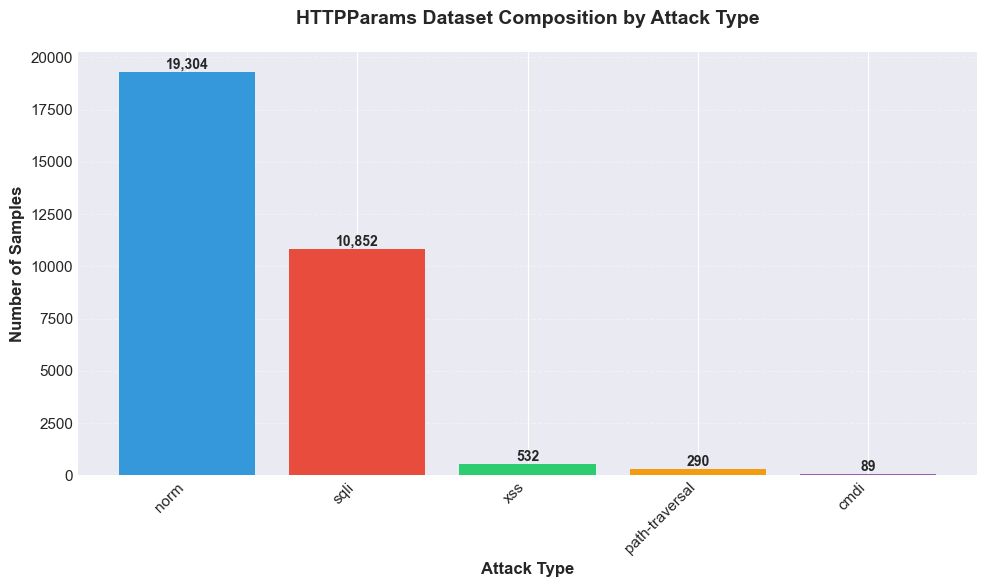


Dataset Statistics:
Total samples: 31,067

Class distribution:
  norm: 19,304 (62.14%)
  sqli: 10,852 (34.93%)
  xss: 532 (1.71%)
  path-traversal: 290 (0.93%)
  cmdi: 89 (0.29%)


In [23]:
full_df = pd.concat([train, test])

# Visualize dataset composition
type_counts = full_df['attack_type'].value_counts()
plt.figure(figsize=(10, 6))
bars = plt.bar(type_counts.index, type_counts.values, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c'])
plt.title('HTTPParams Dataset Composition by Attack Type', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Attack Type', fontsize=12, fontweight='bold')
plt.ylabel('Number of Samples', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Display statistics
print(f"\nDataset Statistics:")
print(f"Total samples: {len(full_df):,}")
print(f"\nClass distribution:")
for attack_type, count in type_counts.items():
    percentage = (count / len(full_df)) * 100
    print(f"  {attack_type}: {count:,} ({percentage:.2f}%)")

In [24]:
# Display first 10 rows
full_df.head(10)

,payload,attack_type
0,c/ caridad s/n,norm
1,"campello, el",norm
2,1442431887503330,norm
3,nue37,norm
4,tufts3@joll.rs,norm
5,22997112x,norm
6,arenas de san juan,norm
7,19245,norm
8,fennell,norm
9,d50allecido,norm


In [25]:
full_df.to_json('HTTPParams.json', 'records')

C:\Users\mps\AppData\Local\Temp\ipykernel_15124\2484948538.py:1: FutureWarning: Starting with pandas version 3.0 all arguments of to_json except for the argument 'path_or_buf' will be keyword-only.
  full_df.to_json('HTTPParams.json', 'records')


In [26]:
import json

In [27]:
with open('HTTPParams.json', 'r') as f:
    custom = json.load(f)

In [28]:
# Display first 10 rows
custom[:10]

[{'payload': 'c/ caridad s/n', 'attack_type': 'norm'},
 {'payload': 'campello, el', 'attack_type': 'norm'},
 {'payload': '1442431887503330', 'attack_type': 'norm'},
 {'payload': 'nue37', 'attack_type': 'norm'},
 {'payload': 'tufts3@joll.rs', 'attack_type': 'norm'},
 {'payload': '22997112x', 'attack_type': 'norm'},
 {'payload': 'arenas de san juan', 'attack_type': 'norm'},
 {'payload': '19245', 'attack_type': 'norm'},
 {'payload': 'fennell', 'attack_type': 'norm'},
 {'payload': 'd50allecido', 'attack_type': 'norm'}]